In [1]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

In [2]:
grid_dir='/meddy/simingzhang/Data/RB_iceland_data/'
wave_dir='/meddy/simingzhang/Data/Parcels_data/'
grdname='niskin2km_500m_grd.nc'


grdname=f'{grid_dir}{grdname}'

wavename=f'{wave_dir}HIT2dcase_modified_cg_nowin.nc'
nowavename=f'{wave_dir}nowavecase_modified_cg_nowin.nc'

In [50]:
outputwavename=f'{wave_dir}/HIT2d_pars_P10000T20.0seconds.zarr'
ds = xr.open_zarr(outputwavename)


In [51]:
ds

<xarray.Dataset> Size: 471MB
Dimensions:     (trajectory: 10000, obs: 173)
Coordinates:
  * obs         (obs) int32 692B 0 1 2 3 4 5 6 7 ... 166 167 168 169 170 171 172
  * trajectory  (trajectory) int64 80kB 31414 31415 31416 ... 41411 41412 41413
Data variables: (12/67)
    lat         (trajectory, obs) float32 7MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
    lon         (trajectory, obs) float32 7MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
    th10        (trajectory, obs) float32 7MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
    th102       (trajectory, obs) float32 7MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
    th108       (trajectory, obs) float32 7MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
    th11        (trajectory, obs) float32 7MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
    ...          ...
    th90        (trajectory, obs) float32 7MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
    th96        (trajectory, obs) float32 7MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
    time        (trajectory, obs) timedelta64[ns] 14MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
    ue          (trajectory, obs) float32 7MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
    ve          (trajectory, obs) float32 7MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
    z           (trajectory, obs) float32 7MB dask.array<chunksize=(10000, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4periodicBCSampleT
    parcels_mesh:           flat
    parcels_version:        3.1.2

In [52]:
output_dir='/meddy/simingzhang/Data/HIT2D/2dt2'


grid_dir='/meddy/simingzhang/Data/HIT2D/2dt2'

# os.chdir(grid_dir)

import scipy.io as sio
from tqdm import tqdm
grid=sio.loadmat(f'{grid_dir}/HIT2D_Parameters.mat')
Diag=grid['Diag']
mm=grid['mm']
kk=grid['kk']
u=np.zeros((199,512,512))
v=np.zeros_like(u)

for i in tqdm(range(0,199)):
    fname=f'{output_dir}/HIT2D_t_{i+4000}.mat'
    data=sio.loadmat(fname)
    hq=data['hq']
    
    hpsi=Diag*hq;
    hu1=-1j*mm*hpsi;
    hw1=1j*kk*hpsi;
    u[i,:,:]=np.real(np.fft.ifft2(hu1))
    v[i,:,:]=np.real(np.fft.ifft2(hw1))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:05<00:00, 35.90it/s]


In [53]:
dx=2*np.pi/512
dy=dx
vx=u2rho_3d(v[:,:,1:]-v[:,:,:-1])/dx
uy=v2rho_3d(u[:,1:,:]-u[:,:-1,:])/dy
vor=(vx-uy)/1000
spd=np.sqrt(u**2+v**2)

x=(np.arange(512)+1)*2*np.pi/512
y=x
X,Y=np.meshgrid(x,y)


In [73]:
tin=14
tin2=41
lons = ds.lon[:, tin].values
lats = ds.lat[:, tin].values
ues = ds.ue[:, tin].values
ves = ds.ve[:, tin].values

Text(0.5, 1.0, 'Timestep = 41 Lag v [m/s]')

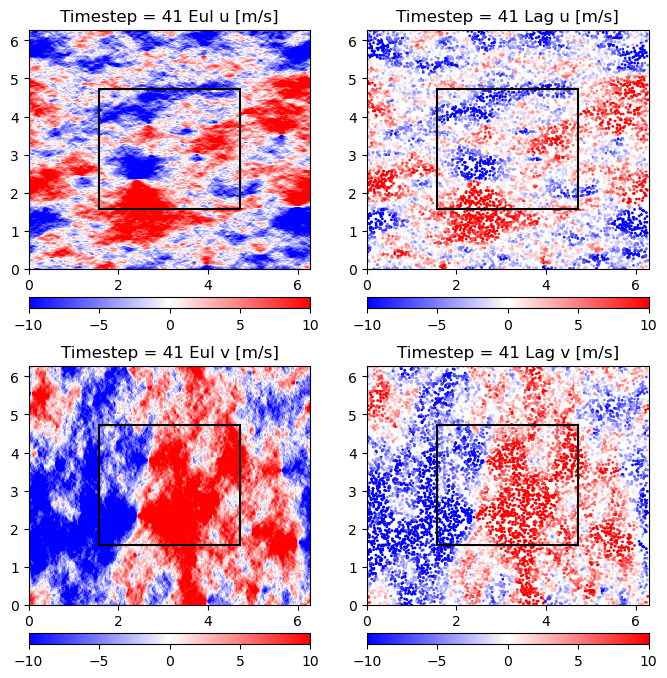

In [74]:
import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec
from matplotlib.colors import SymLogNorm
from matplotlib.colors import Normalize
from cmocean import cm

# 创建图形和网格布局
fig2 = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 2, figure=fig2)  # 2行2列

# 左列子图使用 PlateCarree 投影
ax00 = fig2.add_subplot(gs[0, 0])
ax10 = fig2.add_subplot(gs[1, 0])

# 右列子图不使用投影
ax01 = fig2.add_subplot(gs[0, 1])
ax11 = fig2.add_subplot(gs[1, 1])



# 定义坐标轴对象数组
ax2 = [[ax00, ax01], [ax10, ax11]]

cs2=ax2[0][0].pcolormesh(X,Y,u[tin2,:,:],cmap='bwr',vmin=-10,vmax=10)
colorbar1 = fig2.colorbar(cs2, ax=ax2[0][0], orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)
pio2=np.pi/2
pi3o2=np.pi*3/2
ax2[0][0].plot([pio2,pio2],[pio2,pi3o2],color='k')
ax2[0][0].plot([pi3o2,pi3o2],[pio2,pi3o2],color='k')
ax2[0][0].plot([pio2,pi3o2],[pio2,pio2],color='k')
ax2[0][0].plot([pio2,pi3o2],[pi3o2,pi3o2],color='k')
ax2[0][0].set_xlim([0,2*np.pi])
ax2[0][0].set_ylim([0,2*np.pi])
ax2[0][0].set_title(f'Timestep = {tin2} Eul u [m/s]')




cs2 = ax2[0][1].scatter(lons, lats,  c=ues, cmap='bwr', vmin=-10, vmax=10, s=1 )
colorbar1 = fig2.colorbar(cs2, ax=ax2[0][1], orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)
ax2[0][1].plot([pio2,pio2],[pio2,pi3o2],color='k')
ax2[0][1].plot([pi3o2,pi3o2],[pio2,pi3o2],color='k')
ax2[0][1].plot([pio2,pi3o2],[pio2,pio2],color='k')
ax2[0][1].plot([pio2,pi3o2],[pi3o2,pi3o2],color='k')
ax2[0][1].set_xlim([0,2*np.pi])
ax2[0][1].set_ylim([0,2*np.pi])
ax2[0][1].set_title(f'Timestep = {tin2} Lag u [m/s]')


cs2=ax2[1][0].pcolormesh(X,Y,v[tin2,:,:],cmap='bwr',vmin=-10,vmax=10)
colorbar1 = fig2.colorbar(cs2, ax=ax2[1][0], orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)
pio2=np.pi/2
pi3o2=np.pi*3/2
ax2[1][0].plot([pio2,pio2],[pio2,pi3o2],color='k')
ax2[1][0].plot([pi3o2,pi3o2],[pio2,pi3o2],color='k')
ax2[1][0].plot([pio2,pi3o2],[pio2,pio2],color='k')
ax2[1][0].plot([pio2,pi3o2],[pi3o2,pi3o2],color='k')
ax2[1][0].set_xlim([0,2*np.pi])
ax2[1][0].set_ylim([0,2*np.pi])
ax2[1][0].set_title(f'Timestep = {tin2} Eul v [m/s]')




cs2 = ax2[1][1].scatter(lons, lats,  c=ves, cmap='bwr', vmin=-10, vmax=10, s=1 )
colorbar1 = fig2.colorbar(cs2, ax=ax2[1][1], orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)
ax2[1][1].plot([pio2,pio2],[pio2,pi3o2],color='k')
ax2[1][1].plot([pi3o2,pi3o2],[pio2,pi3o2],color='k')
ax2[1][1].plot([pio2,pi3o2],[pio2,pio2],color='k')
ax2[1][1].plot([pio2,pi3o2],[pi3o2,pi3o2],color='k')
ax2[1][1].set_xlim([0,2*np.pi])
ax2[1][1].set_ylim([0,2*np.pi])
ax2[1][1].set_title(f'Timestep = {tin2} Lag v [m/s]')


In [56]:
# time_id = np.where(ds["time"] == timerange[0])
# ds["lon"].values[time_id].shape
# traj_id=[200,400,500,800,1200]
ds["lon"].values.shape

(10000, 173)

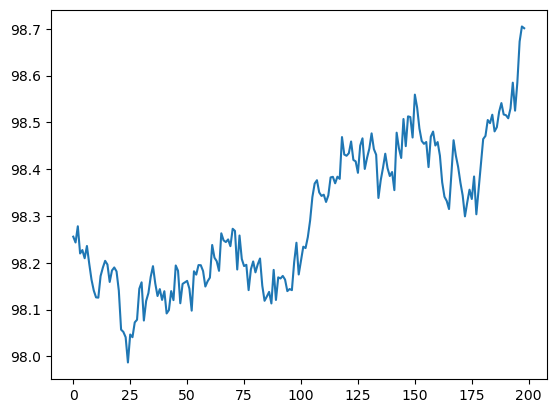

In [57]:
plt.plot(np.nanmean(u**2+v**2,axis=(1,2)))

/tmp/ipykernel_374301/3936979602.py:2: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 800x800 with 8 Axes> which fig.colorbar is called on.
  colorbar1 = fig2.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)


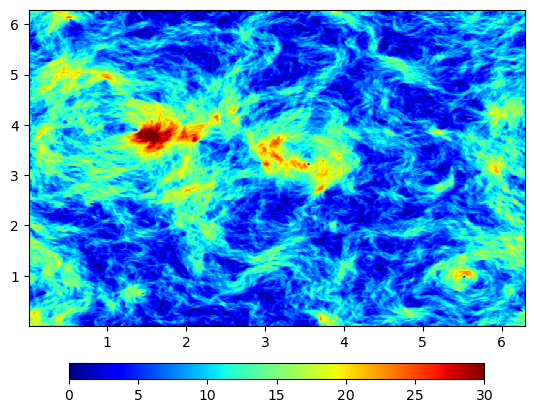

In [58]:
cs2=plt.pcolormesh(X,Y,spd[tin,:,:],cmap='jet',vmin=0,vmax=30)
colorbar1 = fig2.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)

In [65]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# # 假设您的数据
# # ds['lon'].values: 形状 (粒子数, 时间步数)
# # ds['lat'].values: 形状 (粒子数, 时间步数)
# # vor: 形状 (时间步数, 高度, 宽度)


# selected_indices = np.arange(10000)  # 直接使用行索引

# # 提取位置数据
# particle_lons = ds['lon'].values[selected_indices, :]
# particle_lats = ds['lat'].values[selected_indices, :]


# # 获取时间步数
# num_timesteps = 173

# # 创建图形
# fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# # 初始时间步
# tin = 0

# # 绘制初始涡度场
# vor_img = ax.pcolormesh(X,Y,vor[tin, :, :], 
#                     cmap='bwr', 
#                     vmin=-1.5, 
#                     vmax=1.5,
#                    )  # 假设域大小为6.28x6.28
# # vor_img = ax.pcolormesh(X,Y,spd[tin, :, :], 
# #                     cmap='jet', 
# #                     vmin=0, 
# #                     vmax=30,
# #                    )  # 假设域大小为6.28x6.28

# # 添加颜色条
# cbar = fig.colorbar(vor_img, ax=ax)
# cbar.set_label('speed magn')

# # 绘制初始粒子位置
# sc = ax.scatter(particle_lons[:, tin], 
#                 particle_lats[:, tin], 
#                 s=5, 
#                 c='green', 
#                 edgecolor='black',alpha=0.5)

# # 设置标题
# title = ax.set_title(f"Particles 100-149 at t = {tin}")

# def animate(i):
#     # 更新涡度场
#     vor_img.set_array(vor[i, :, :])
#     # vor_img.set_array(spd[i, :, :])
#     # 更新粒子位置
#     sc.set_offsets(np.c_[particle_lons[:, i], particle_lats[:, i]])
    
#     # 更新标题
#     title.set_text(f"Some particles at t = {i}")
    
#     return vor_img, sc, title

# # 创建动画
# anim = FuncAnimation(fig, animate, frames=num_timesteps, interval=200, blit=True)

In [63]:
# HTML(anim.to_jshtml())
# HTML(anim.to_html5_video())


In [64]:
anim.save('some_animation10000.gif', writer='pillow', fps=20)

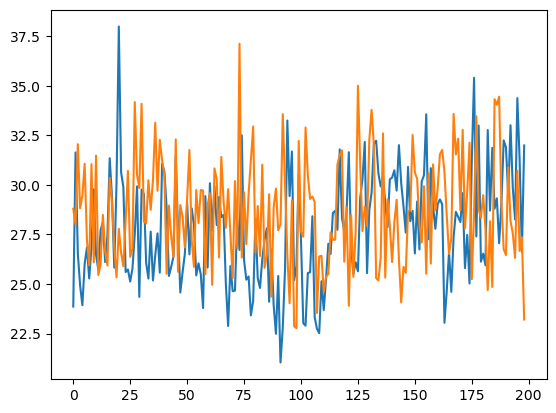

In [47]:
plt.plot(np.max(np.abs(u),axis=(1,2)))
plt.plot(np.max(np.abs(v),axis=(1,2)))

In [46]:
import parcels
print(parcels.__file__)

/home/simingzhang/anaconda3/lib/python3.12/site-packages/parcels/__init__.py
